# 1 - Data Pre-processing (15 Marks):

In [2]:
import numpy as np
from scipy import stats
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
# Upload dataset from GitHub using trick given by the T.A on Piazza

data_path = "https://raw.githubusercontent.com/Sofiane-Sif/YieldPrediction/main/yield_prediction.csv"
data = pd.read_csv(data_path, index_col="id")

print("Shape of the dataset: ", data.shape)
data.head()

Shape of the dataset:  (1000, 8)


,water,uv,area,fertilizer_usage,yield,pesticides,region,categories
id,,,,,,,,
0,0.072,80.179,9.414,0,29.878,2.231,6,c
1,5.413,58.359,9.681,3,53.416,1.810,6,c
2,9.731,78.506,7.189,1,63.391,2.455,1,d
3,10.995,69.248,1.738,3,17.984,0.603,2,a
4,2.617,87.658,9.706,1,49.768,2.910,6,c


### Since all variables are expressed as being per hectare (e.g. water, uv, area), it makes more sense to consider yield per hectare also.

In [4]:
data["yield"] = data["yield"] / data["area"]
data= data.rename(columns={"yield": "yieldPerHec"})
data.head()

,water,uv,area,fertilizer_usage,yieldPerHec,pesticides,region,categories
id,,,,,,,,
0,0.072,80.179,9.414,0,3.173784,2.231,6,c
1,5.413,58.359,9.681,3,5.517612,1.810,6,c
2,9.731,78.506,7.189,1,8.817777,2.455,1,d
3,10.995,69.248,1.738,3,10.347526,0.603,2,a
4,2.617,87.658,9.706,1,5.127550,2.910,6,c


### First of all, we will deal with categorical data (column 'categories') and we will use one-hot encoding since this column does not correspond to ordinal data.

In [5]:
one_hot_pest = data['categories'].str.get_dummies(sep=',').add_prefix('pest_') # one-hot based on the type of pesticides used

data = pd.concat([data, one_hot_pest], axis=1)
data.drop("categories", axis=1, inplace=True)
data.head()

,water,uv,area,fertilizer_usage,yieldPerHec,pesticides,region,pest_a,pest_c,pest_d
id,,,,,,,,,,
0,0.072,80.179,9.414,0,3.173784,2.231,6,0,1,0
1,5.413,58.359,9.681,3,5.517612,1.810,6,0,1,0
2,9.731,78.506,7.189,1,8.817777,2.455,1,0,0,1
3,10.995,69.248,1.738,3,10.347526,0.603,2,1,0,0
4,2.617,87.658,9.706,1,5.127550,2.910,6,0,1,0


### Then, we have to adress the missing values problem (zero or NaN values)

In [6]:
print("Number of zeros or NaN values per class: ")
data.isna().sum()

Number of zeros or NaN values per class: 


water               42
uv                   0
area                 0
fertilizer_usage     0
yieldPerHec          0
pesticides           0
region               0
pest_a               0
pest_c               0
pest_d               0
dtype: int64

### We can see that only water contains missing values. We will impute these missing values by taking the median of the other water values, as it is more robust to outliers compared to the mean.

In [7]:
simple_imputer = SimpleImputer(missing_values=np.nan, strategy="median")

data["water"] = simple_imputer.fit_transform(np.array(data["water"]).reshape(-1,1))
data.head()

# check that all NaN values has been imputed
print(f"Number of NaN values for water data: {data['water'].isna().sum()}")

Number of NaN values for water data: 0


### Now, let's take a look at outliers data

In [8]:
z_scores = np.abs(stats.zscore(data.select_dtypes(include=[np.number])))
outliers = (z_scores > 3) # consider outlier if z-score > 3 or < -3 (i.e datapoint at least 3 standard deviation away from the mean)

print("Number of outliers per class: ")
print(outliers.sum())

Number of outliers per class: 
water               2
uv                  2
area                3
fertilizer_usage    0
yieldPerHec         0
pesticides          0
region              0
pest_a              0
pest_c              0
pest_d              0
dtype: int64


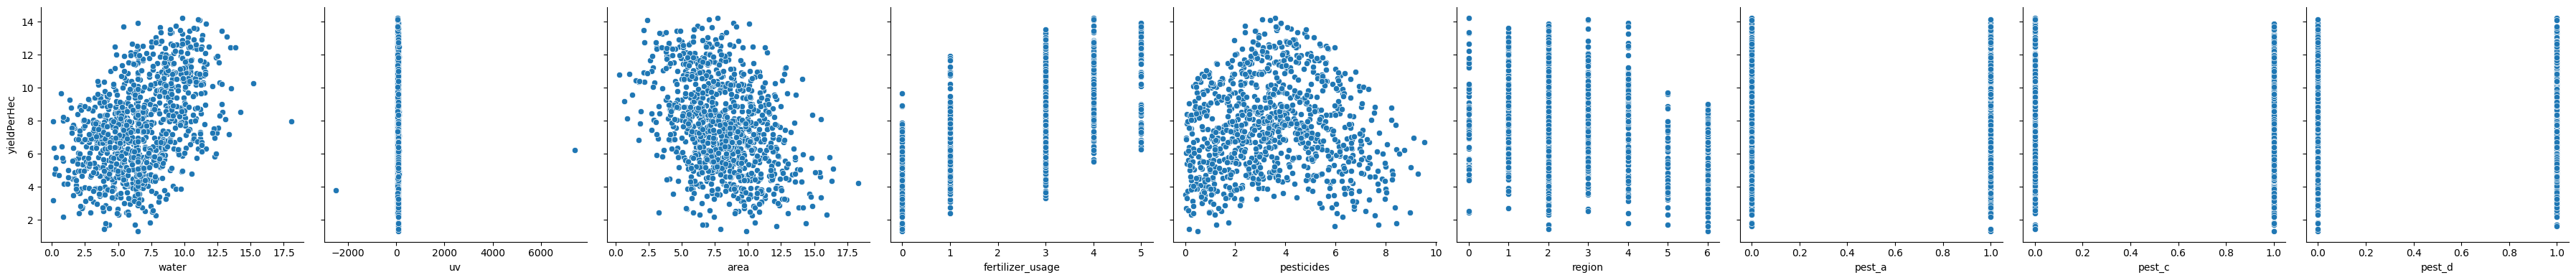

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Adjust the column names as necessary. Assuming the yield column is just "yield" based on your dataset description.
y_variable = 'yieldPerHec'  # or "yieldPerHec" if that's the actual column name
x_variables = data.columns.drop([y_variable])  # Exclude the yield from the x variables

# Create the pairplot for outliers detection
sns.pairplot(data, x_vars=x_variables, y_vars=[y_variable], diag_kind=None, height=4, aspect=1)

plt.tight_layout()
plt.show()

#### Based on this plot, we clearly see 2 extreme outliers for 'uv', and some other outliers for 'water' and 'area', but not as extreme as outliers for 'uv'. This is consistent with the Number of outlier per class print just above.

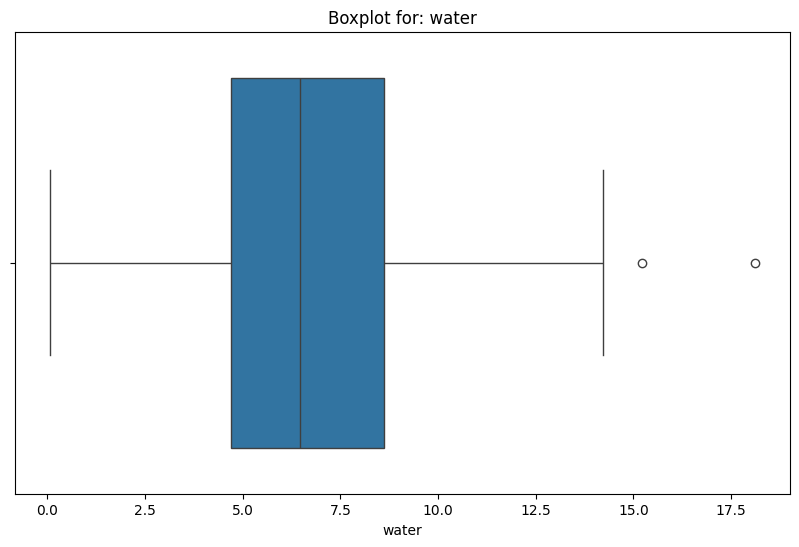

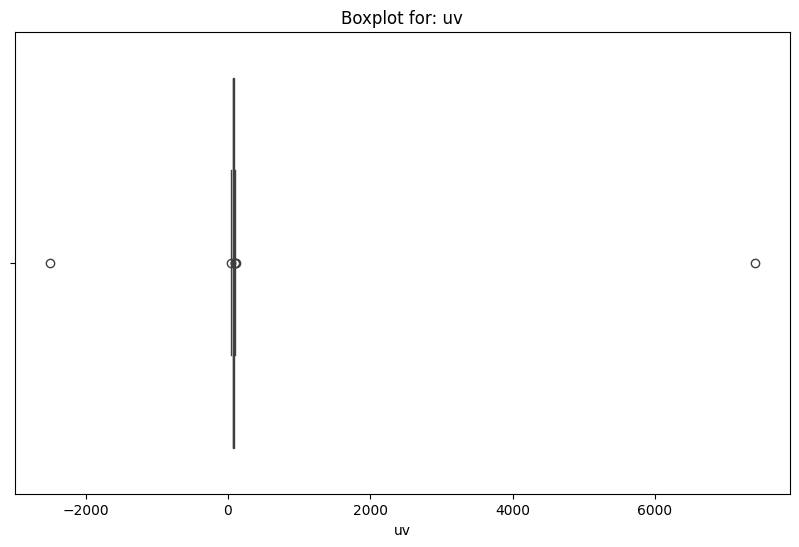

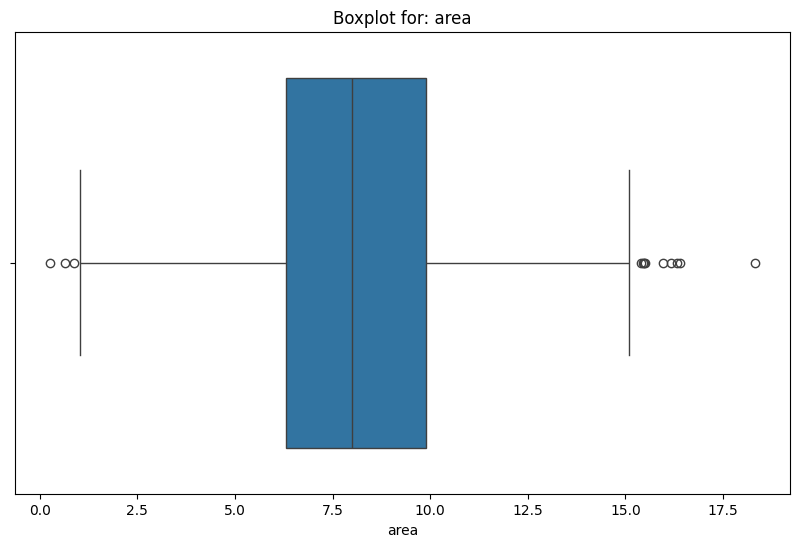

In [10]:
# Plotting boxplots for 'water', 'uv' and 'area'
outliers_list = ["water", "uv", "area"]

for column in outliers_list:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=data[column])
    plt.title(f"Boxplot for: {column}")
    plt.show()

#### Based on this outliers detection analysis, we will implement the following pipeline:

#### - Remove outliers data points for "uv" that are clearly very extreme outliers
#### - Replace outliers data points for "water" and "area" by the median of their corresponding distribution

In [11]:
data_filtered = data[z_scores["uv"] < 3] # removing extreme outliers data point for UV

def replace_outliers_with_median_using_zscore(df, column):
    # Calculate Z-scores for the specified column
    z_scores_column = np.abs(stats.zscore(df[column]))

    # Calculate the median of the column
    median = df[column].median()

    # Replace outliers (where Z-score > 3) with the column's median
    df[column] = np.where(z_scores_column > 3, median, df[column])

# Recalculate Z-scores for 'water' and 'area' in the filtered dataset without extreme 'uv' outliers
replace_outliers_with_median_using_zscore(data_filtered, 'water')
replace_outliers_with_median_using_zscore(data_filtered, 'area')


<ipython-input-11-949d85835d90>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = np.where(z_scores_column > 3, median, df[column])
<ipython-input-11-949d85835d90>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = np.where(z_scores_column > 3, median, df[column])


#### We can now plot again the pairplot to see the difference. We can notice that removing outliers for 'uv' allow us to visualize the distribution of this class with respect to yieldPerHec.

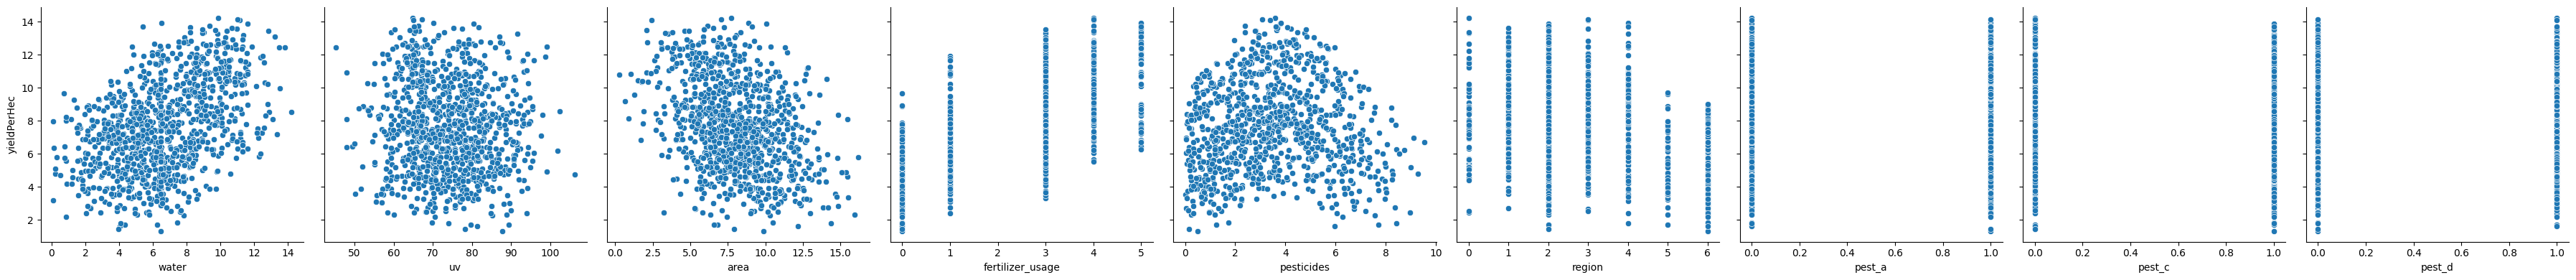

In [12]:
y_variable = 'yieldPerHec'
x_variables = data_filtered.columns.drop([y_variable])

# Pairplot without outliers
sns.pairplot(data_filtered, x_vars=x_variables, y_vars=[y_variable], height=4, aspect=1)

plt.tight_layout()
plt.show()

### Train-Val-Test splitting (ratio 60:20:20)

In [13]:
X = data_filtered.drop("yieldPerHec", axis=1)
y = data_filtered["yieldPerHec"]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

print("X_train shape: ", X_train.shape)
print("X_val shape: ", X_val.shape)
print("X_test shape: ", X_test.shape)


X_train shape:  (598, 9)
X_val shape:  (200, 9)
X_test shape:  (200, 9)


# 2 - Regression Tree Optimization (30 Marks)

### First we load a generic regression tree using sklearn library, the parameters such as Minimum Split Size, Minimum Leaf Size, Maximum Depth are taken as values to impose least amount of restriction on the descision tree.

### The first tree (Named Regressor) is the Pre-pruned Tree

Mean Squared Error PRE PRUNING: 2.4537665978535856


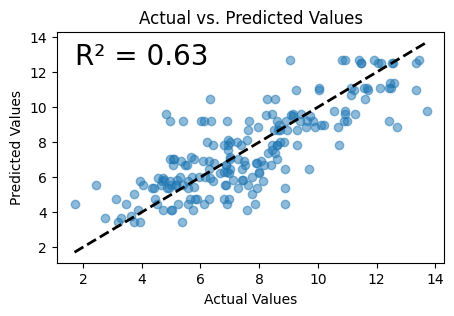

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

regressor = DecisionTreeRegressor(criterion='squared_error', splitter='random', max_depth=None, min_samples_split=2, min_samples_leaf=10, min_weight_fraction_leaf=0.0, max_features=9, random_state=42)

regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)
mse = mean_squared_error(y_test, predictions)

print(f"Mean Squared Error PRE PRUNING: {mse}")

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions)
plt.figure(figsize=(5, 3))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.text(min_val, max_val, f'R² = {r2:.2f}', fontsize=20, verticalalignment='top', horizontalalignment='left')
plt.show()


### We can observe that the R2 score on Test set is not high, and higher amount of variance is observed as well. this points to the situation of overfitting. We can also visualise the "Regressor" Tree learned curated during inference.

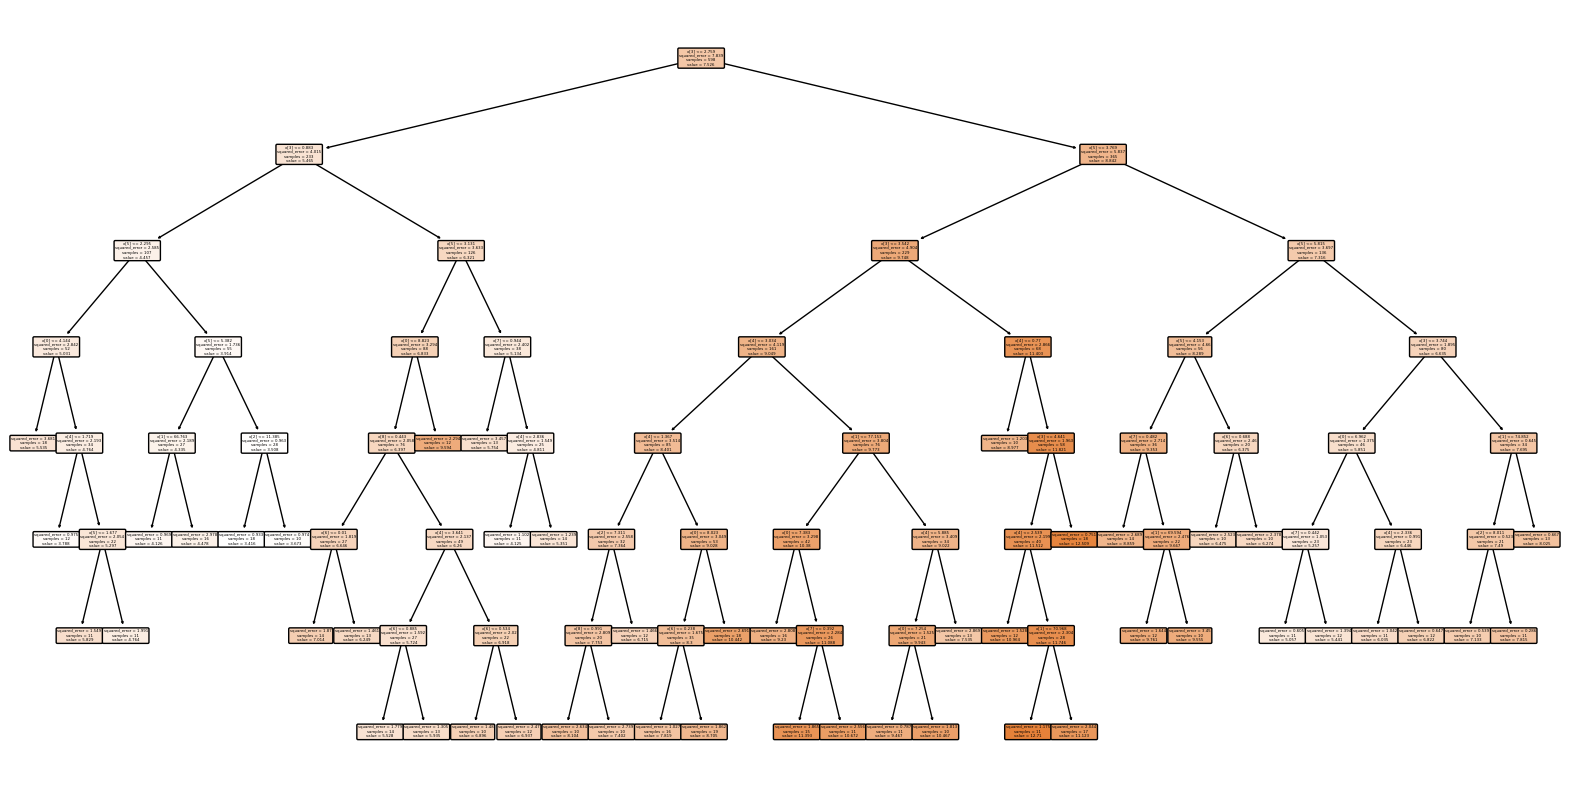

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
plt.figure(figsize=(20,10))
plot_tree(regressor, filled=True, rounded=True)
plt.show()

### Here we perform the task of pruning wiothout taking any aid of a library or any optimizer, the strategy here is just to randomply prune the tree above
#### The methodology of pruning is simple - we extract the tree structure from it's class. Obtain the list of indexes of children nodes for each node, and by randomly choosing some nodes we set their children to null (i.e node index -1). The nodes whose children are set to null, end up becoming leaf nodes.

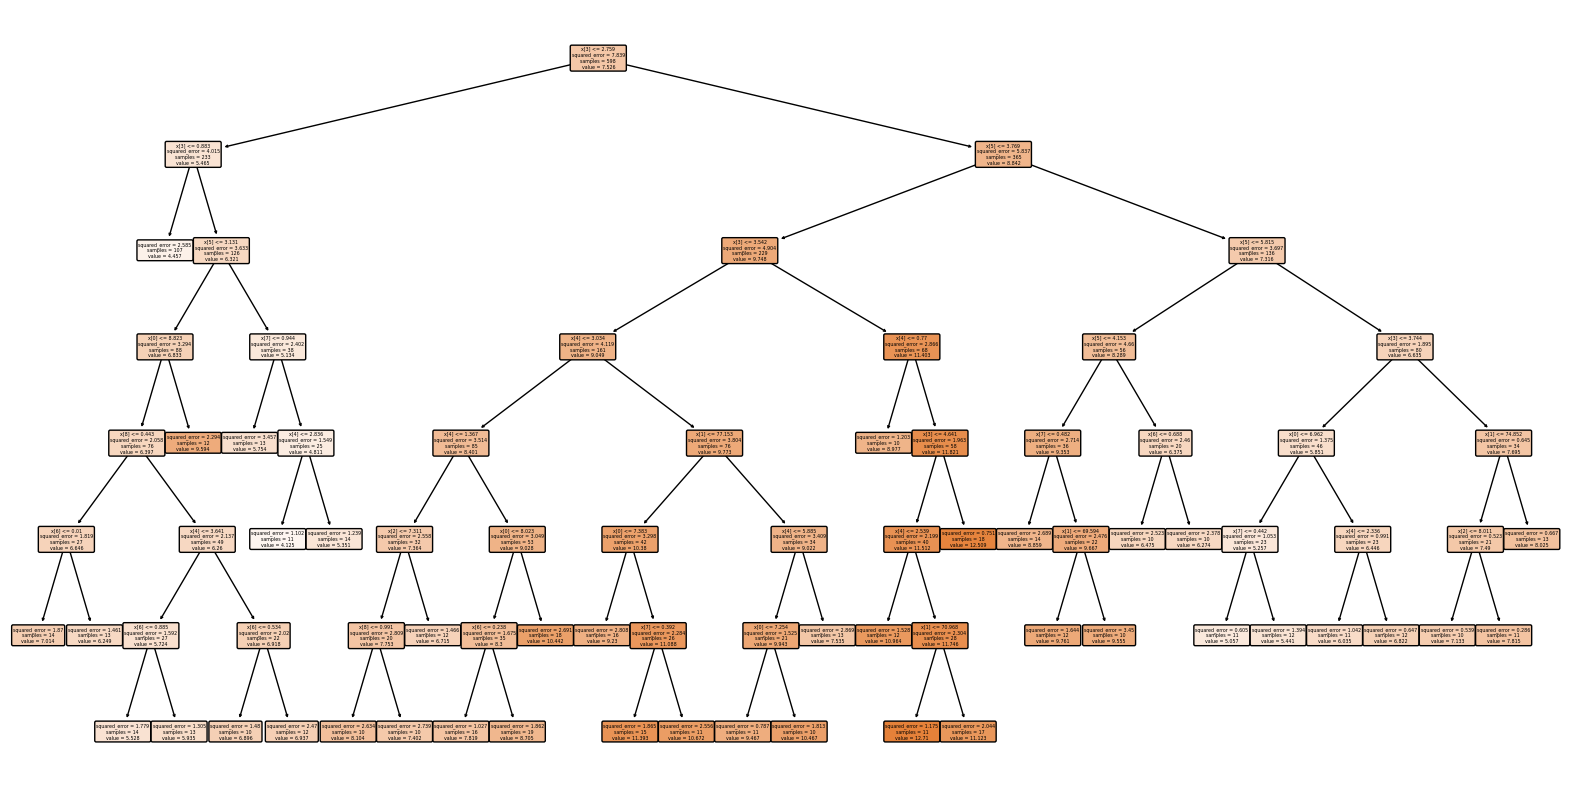

Mean Squared Error POST PRUNING: 2.5968365813546335


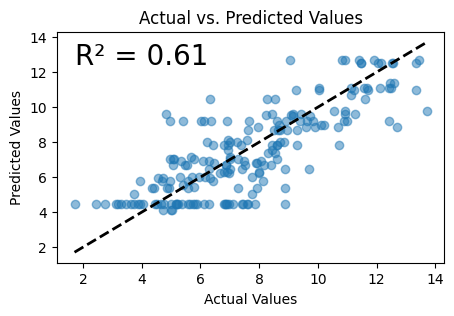

In [ ]:
tree_structure = regressor.tree_   # Extract tree stucture


#Set children of nodel labelled as 5,13,2,10 as null

tree_structure.children_left[5] = -1
tree_structure.children_left[13] = -1
tree_structure.children_left[2] = -1
tree_structure.children_left[10] = -1

# Plot pruned tree

from sklearn.tree import DecisionTreeRegressor, plot_tree
plt.figure(figsize=(20,10))
plot_tree(regressor, filled=True, rounded=True)
plt.show()

#Calculate Mse and R2 score

predictions = regressor.predict(X_test)
mse = mean_squared_error(y_test, predictions)

print(f"Mean Squared Error POST PRUNING: {mse}")

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions)
plt.figure(figsize=(5, 3))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.text(min_val, max_val, f'R² = {r2:.2f}', fontsize=20, verticalalignment='top', horizontalalignment='left')
plt.show()

### Intresetingly, through random manual pruning the MSE error is even higher and the Tree is likely underfit now.

### Here, we utilise sklearn library to impute the tree, and then select the best tree wrt the parameter alpha (In the context of pruning a decision tree, "alpha" refers to a complexity parameter that is part of cost complexity pruning, also known as "alpha pruning" or "minimal cost-complexity pruning." )

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

tree = DecisionTreeRegressor(max_depth=None, min_samples_split=2, min_samples_leaf=2,random_state=0)
tree.fit(X_train, y_train)

# Determine the effective alphas for pruning
path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Evaluate the performance of trees for each alpha
scores = []
scorest= []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeRegressor(random_state=0, ccp_alpha=ccp_alpha)
    score = cross_val_score(tree, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    scoret = cross_val_score(tree, X_test, y_test, cv=5, scoring='neg_mean_squared_error')
    scorest.append(np.mean(scoret))
    scores.append(np.mean(score))



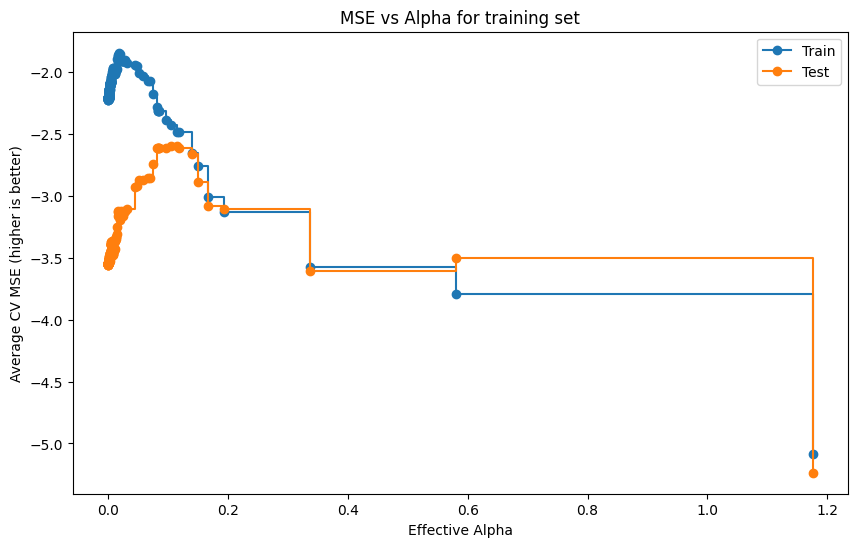

DecisionTreeRegressor(ccp_alpha=0.018803306557448163, min_samples_leaf=5,
                      random_state=0)

In [ ]:
# Plot the MSE (mean squared error) of the trees as a function of ccp_alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas[:-1], scores[:-1], marker='o', drawstyle="steps-post", label = "Train")
plt.plot(ccp_alphas[:-1], scorest[:-1], marker='o', drawstyle="steps-post", label = "Test")

plt.xlabel('Effective Alpha')
plt.ylabel('Average CV MSE (higher is better)')
plt.title('MSE vs Alpha for training set')

plt.legend()
plt.show()

# Select the optimal ccp_alpha that maximizes the negative MSE (minimizes MSE)
optimal_ccp_alpha = ccp_alphas[np.argmax(scores[:-1])]

# Re-train the decision tree regressor using the optimal ccp_alpha
tree_pruned = DecisionTreeRegressor(min_samples_split=2, min_samples_leaf=5,random_state=0, ccp_alpha=optimal_ccp_alpha)
tree_pruned.fit(X_train, y_train)


Mean Squared Error PRE PRUNING: 1.7012386132876778


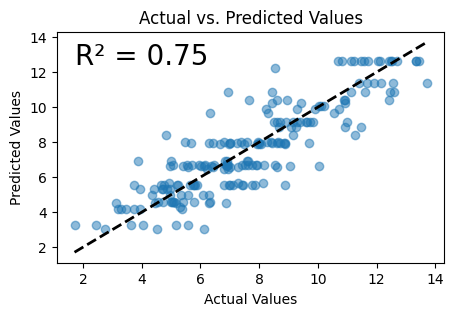

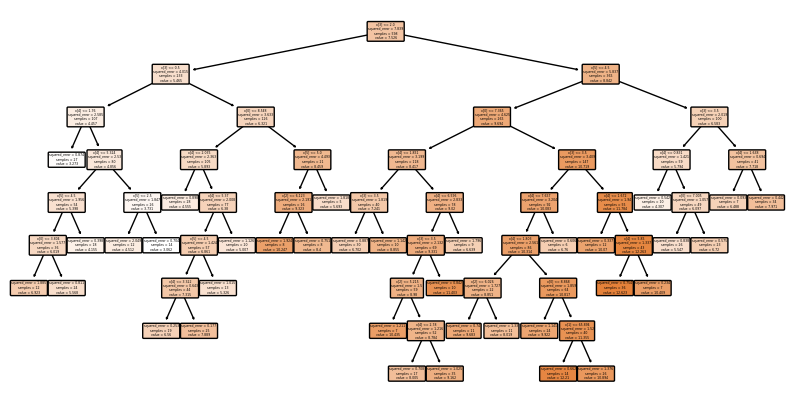

In [ ]:
predictions = tree_pruned.predict(X_test)
mse = mean_squared_error(y_test, predictions)

print(f"Mean Squared Error PRE PRUNING: {mse}")

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
r2 = r2_score(y_test, predictions)
plt.figure(figsize=(5, 3))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.text(min_val, max_val, f'R² = {r2:.2f}', fontsize=20, verticalalignment='top', horizontalalignment='left')
plt.show()

print("  ")

from sklearn.tree import DecisionTreeRegressor, plot_tree
plt.figure(figsize=(10,5))
plot_tree(tree_pruned, filled=True, rounded=True)
plt.show()

### We observe that cost-complexity pruning by sklearn gives the best result and highest R2 score

# 3 - Comparison with Random Forest and SVR (25 Marks)



### Desicion Trees Regressor

In [14]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10, 20],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 10]  # Minimum number of samples required to be at a leaf node
}

dt = DecisionTreeRegressor(random_state=42)
# Since grid search internally perform cross-validation on the train set,
# we concatenate the train and validation set
X_train_grid_search = pd.concat((X_train, X_val), axis=0) # scaling don't needed for Decision Trees based regressor
y_train_grid_search = pd.concat((y_train, y_val), axis=0)

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
  )

grid_search_dt.fit(X_train_grid_search, y_train_grid_search)

print("Best parameters for Decision Trees Regressor:", grid_search_dt.best_params_)


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters for Decision Trees Regressor: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [16]:
from sklearn.metrics import mean_squared_error

# Select best Decision Tree model
best_dt = grid_search_dt.best_estimator_

y_test_pred_dt = best_dt.predict(X_test)
mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
print("Test MSE for Decision Tree:", mse_test_dt)

# y_train_pred_dt = best_dt.predict(X_train_grid_search)
# mse_train_dt = mean_squared_error(y_train_grid_search, y_train_pred_dt)
# print("Train MSE for DT:", mse_train_dt)

Test MSE for Decision Tree: 1.3922941169384992


### Random Forest regressor

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)
# Since grid search internally perform cross-validation, we concatenate the train
# and validation set
X_train_grid_search = pd.concat((X_train, X_val), axis=0)
y_train_grid_search = pd.concat((y_train, y_val), axis=0)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
  )

grid_search.fit(X_train_grid_search, y_train_grid_search)

print("Best parameters for Random Forest Regressor:", grid_search.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for Random Forest Regressor: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}


In [18]:
from sklearn.metrics import mean_squared_error

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rf)
print("Test MSE:", mse)

# y_train_pred_rf = best_rf.predict(X_train_grid_search)
# mse_train_rf = mean_squared_error(y_train_grid_search, y_train_pred_rf)
# print("Train MSE for RF:", mse_train_rf)

Test MSE: 1.0740464751404217


In [ ]:
# Saving the Best Random Forest Regressor locally

from google.colab import files
from joblib import dump

model_filename = 'best_rf.joblib'
dump(best_rf, model_filename)

files.download(model_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Support Vector Regressor

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_normalized = scaler.transform(X_train)
X_val_normalized = scaler.transform(X_val)
X_test_normalized = scaler.transform(X_test)

In [20]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'C': [0.1, 1, 10, 15, 20],  # Regularization parameter
    'gamma': ['scale', 'auto', 0.1, 1, 10],  # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'
    'epsilon': [0.01, 0.1, 0.5],  # Epsilon in the epsilon-SVR model
    'kernel': ['rbf', 'linear']  # Specifies the kernel type to be used in the algorithm
}

X_train_grid_search = pd.concat((pd.DataFrame(X_train_normalized), pd.DataFrame(X_val_normalized)), axis=0)
y_train_grid_search = pd.concat((pd.DataFrame(y_train), pd.DataFrame(y_val)), axis=0)

svr = SVR()
grid_search_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid_svr,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='neg_mean_squared_error'
  )


grid_search_svr.fit(X_train_grid_search, y_train_grid_search)

print("Best parameters for SVR:", grid_search_svr.best_params_)


Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best parameters for SVR: {'C': 10, 'epsilon': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [21]:
best_svr = grid_search_svr.best_estimator_

# Predict and evaluate on the test set
y_test_pred_svr = best_svr.predict(X_test_normalized)
mse_test_svr = mean_squared_error(y_test, y_test_pred_svr)
print("Test MSE for SVR:", mse_test_svr)

# y_train_pred_svr = best_svr.predict(X_train_grid_search)
# mse_train_svr = mean_squared_error(y_train_grid_search, y_train_pred_svr)
# print("Train MSE for SVR:", mse_train_svr)


Test MSE for SVR: 1.4835755386777651


In [ ]:
# Saving the Best Support Vector Regressor locally

from google.colab import files
from joblib import dump

model_filename = 'best_svr.joblib'
dump(best_svr, model_filename)

files.download(model_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 4 - Classification Task (10 Marks)

### Sorting yieldPerHec and assign label 0 ('low') to the lowest 20% and label 1 ('high') to the remaining 80%

In [ ]:
data_sorted_by_yield = data_filtered.sort_values(by="yieldPerHec")
threshold_index = int(len(data_filtered) * 0.2)
threshold_index

# Assign class: 1='high', 0='low'
data_sorted_by_yield['yieldClass'] = 1
data_sorted_by_yield.iloc[:threshold_index, data_sorted_by_yield.columns.get_loc('yieldClass')] = 0

In [ ]:
data_sorted_by_yield["yieldClass"].value_counts() # unbalanced dataset

1    799
0    199
Name: yieldClass, dtype: int64

In [ ]:
# Reordering columns
data_sorted_by_yield = data_sorted_by_yield[['water', 'uv', 'area', 'fertilizer_usage', 'yieldPerHec', 'yieldClass', 'pesticides', 'region', 'pest_a', 'pest_c', 'pest_d']]
data_sorted_by_yield

,water,uv,area,fertilizer_usage,yieldPerHec,yieldClass,pesticides,region,pest_a,pest_c,pest_d
id,,,,,,,,,,,
81,6.476,87.825,9.867,0,1.336070,0,0.494,6,1,1,0
984,3.966,78.208,7.915,0,1.459255,0,0.160,2,1,0,0
398,4.024,81.337,12.166,0,1.624034,0,5.967,6,0,0,1
9,4.321,79.671,6.818,0,1.708712,0,1.255,5,0,0,1
50,6.262,89.391,6.572,0,1.730219,0,7.707,2,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
144,11.625,80.430,10.086,5,13.896193,1,3.794,2,0,1,0
311,6.497,70.258,8.890,5,13.933408,1,3.822,4,1,0,0
491,11.154,65.098,2.415,4,14.097308,1,3.379,3,0,0,1


In [ ]:
# We define training and testing sets for the classificaiton task

X_class = data_sorted_by_yield.drop(["yieldPerHec", "yieldClass"], axis=1)
y_class = data_sorted_by_yield["yieldClass"]

# No validation set here because we will perform GridSearch that will internally
# perform cross-validation using the train set

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    shuffle=True,
    random_state=42
  )

print("X_train_class shape: ", X_train_class.shape)
print("X_test_class shape: ", X_test_class.shape)


X_train_class shape:  (798, 9)
X_test_class shape:  (200, 9)


#### Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
  }
svm_classifier = SVC(random_state=42)

grid_search_svm = GridSearchCV(svm_classifier, param_grid, scoring='f1', n_jobs=-1, cv=5)
grid_search_svm.fit(X_train_class, y_train_class)

print("Best parameters for SVM Classifier: ", grid_search_svm.best_params_)

Best parameters for SVM Classifier:  {'C': 0.1, 'kernel': 'linear'}


#### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 5, 10]
  }
dt_classifier = DecisionTreeClassifier(random_state=42)

grid_search_dt = GridSearchCV(dt_classifier, param_grid_dt, scoring='f1', n_jobs=-1, cv=5)
grid_search_dt.fit(X_train_class, y_train_class)
print("Best parameters for DTs Classifier: ", grid_search_dt.best_params_)

Best parameters for DTs Classifier:  {'max_depth': None, 'min_samples_leaf': 10}


#### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10]
}

rf_classifier = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, scoring='f1', n_jobs=-1, cv=5, verbose=2)

grid_search_rf.fit(X_train_class, y_train_class)
print("Best parameters for Random Forest Classifier: ", grid_search_rf.best_params_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters for Random Forest Classifier:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


#### F1-score of all three classifiers

In [ ]:
from sklearn.metrics import f1_score

# Predictions
y_pred_svm = grid_search_svm.best_estimator_.predict(X_test_class)
y_pred_dt = grid_search_dt.best_estimator_.predict(X_test_class)
y_pred_rf = grid_search_rf.best_estimator_.predict(X_test_class)

# F1-Score
f1_svm = f1_score(y_test_class, y_pred_svm, pos_label=1) # 1 represents class yield 'high'
f1_dt = f1_score(y_test_class, y_pred_dt, pos_label=1)
f1_rf = f1_score(y_test_class, y_pred_rf, pos_label=1)

print(f"F1-Score SVM: {f1_svm}")
print(f"F1-Score DT: {f1_dt}")
print(f"F1-Score RF: {f1_rf}")


F1-Score SVM: 0.9341317365269461
F1-Score DT: 0.9397590361445782
F1-Score RF: 0.9436201780415431


#### PR curve

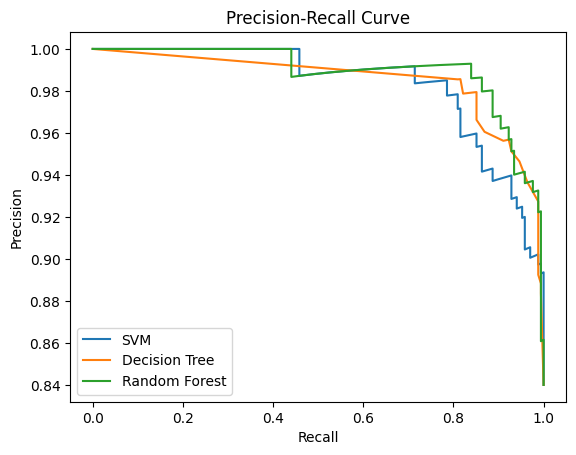

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_scores_svm = grid_search_svm.best_estimator_.decision_function(X_test_class)
y_scores_dt = grid_search_dt.best_estimator_.predict_proba(X_test_class)[:, 1]  # Probabilities for the positive class
y_scores_rf = grid_search_rf.best_estimator_.predict_proba(X_test_class)[:,1]

precision_svm, recall_svm, _ = precision_recall_curve(y_test_class, y_scores_svm, pos_label=1)
precision_dt, recall_dt, _ = precision_recall_curve(y_test_class, y_scores_dt, pos_label=1)
precision_rf, recall_rf, _ = precision_recall_curve(y_test_class, y_scores_rf, pos_label=1)

# Plotting Precision-Recall curves
plt.plot(recall_svm, precision_svm, label='SVM')
plt.plot(recall_dt, precision_dt, label='Decision Tree')
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


# 5 - Regression Tree as a Classifier (20-30 Marks)

In [ ]:
import copy
import math
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
def convert(p, y):
    a = copy.deepcopy(y)
    a.sort()
    thresh_margin = a[math.ceil(a.size*p)]
    #print(thresh_margin)
    arr = copy.deepcopy(y)
    fin = np.where(y < thresh_margin, 0 , 1)
    return fin


In [ ]:
y__ = y_test.values
y_test_ = convert(0.2, y__)
y_pred = tree_pruned.predict(X_test)

In [ ]:
i = 0
auc_val = []
while (i < 100):
    p = i*0.01
    y_pred_ = convert(p, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test_, y_pred_)
    roc_auc = auc(fpr, tpr)
    #print(roc_auc, i)
    auc_val.append(roc_auc)
    i = i+1


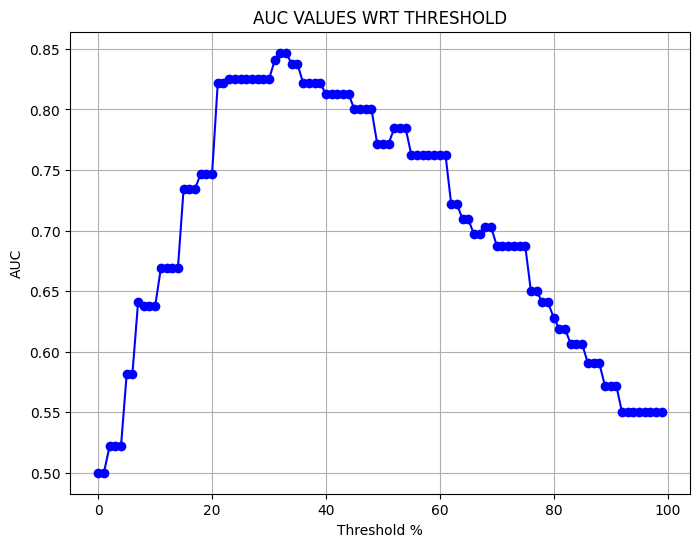

In [ ]:
import matplotlib.pyplot as plt
values = auc_val
plt.figure(figsize=(8, 6))
plt.plot(values, marker='o', linestyle='-', color='b')
plt.title('AUC VALUES WRT THRESHOLD')
plt.xlabel('Threshold %')
plt.ylabel('AUC')
plt.grid(True)
plt.show()

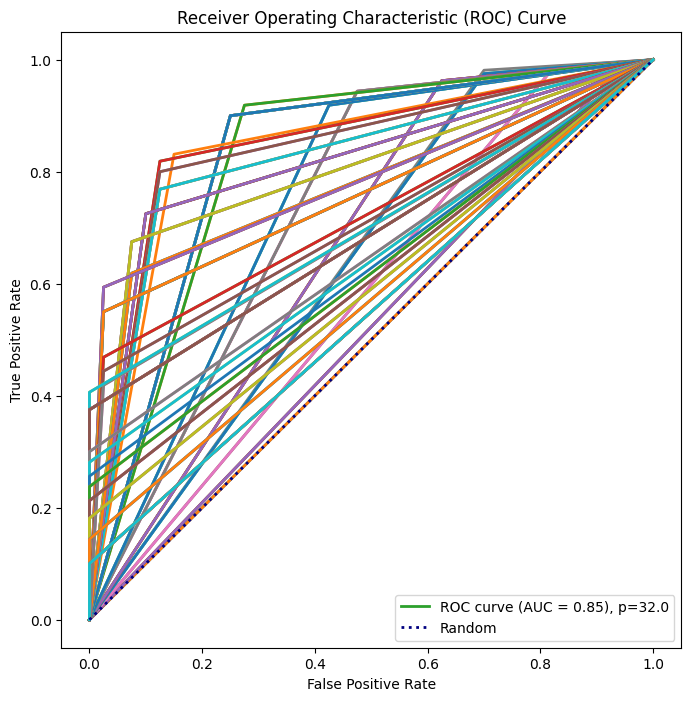

[2 1 0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

index = auc_val.index(max(auc_val))

y_true = y_test_
y_scores = y_pred_
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))

i = 0
while (i < 100):
    p = i*0.01
    #p = 0.99
    y_pred_ = convert(p, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test_, y_pred_)
    roc_auc = auc(fpr, tpr)
    if(i == index):
        plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f}), p={(p*100)//1}')
    else:
        plt.plot(fpr, tpr, lw=2)
    i = i+1

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='dotted', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
print(thresholds)
